# Week 5 Report

**Date:** 2026 - 06 - 23

## Goals for this week

- [ ] Define Scientific Question (or create a few candidates)
- [ ] Create Isotropic Variograms
- [ ] Run Temporal Autocorrelation
- [ ] Rotate Principal Component Loadings

## What I did
Most of this week was spent going down my list of goals and returnables from our past meeting, writing code to perform the operations requested and analyzing the results. Below in the Analysis section, my code for Isotropic Variograms (which I am not confident is working correctly), Temporal Autocorrelations (which I am confident is working correctly), and the rotation of principal component loadings (which I believe is working correctly but does not seem to have done what we had hoped it would) is included.

In [18]:
#Background code (importing libraries, defining functions for later use

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
import scipy as sp
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from factor_analyzer import Rotator
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns

pa_gs = pd.read_csv('/home/reu/project/data/pa_data.csv')
coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]

y = ['growing_season_length']
X = ['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico','sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']

def remove_nulls(data_subset, X, y):
        # Drop rows where any of the specified X columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=X, ignore_index=True)
        # Separate the cleaned dataframe back into X and y
        X_cleaned = data_subset_cleaned[X]
        y_cleaned = data_subset_cleaned[y]
        return X_cleaned, y_cleaned

def multiple_regression(data_subset, input_variables, predicted_variable):
    #performs a standardized multiple linear regression to create a model of y based on the variables within X.
    # Required Libraries: r2score, mean_absolute_error, and mean_squared_error from sklearn.metrics, 
    # train_test_split from sklearn.model_selection, linear_model from sklearn, and StandardScaler from sklearn.preprocessing

    X_cleaned, y_cleaned = remove_nulls(data_subset, input_variables, predicted_variable)

    #counts total data points included in regression
    tot_data_points = len(X_cleaned)
    
    #splits data into training and testing groups
    X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size = 0.2, random_state =0)

    #converts y_train, y_test, and y_cleaned into series
    y_train= y_train.squeeze()
    y_test= y_test.squeeze()
    y_cleaned = y_cleaned.squeeze()
    
    #scales input data to standardize to mean of 0 and standard deviation of 1
    sc = StandardScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.fit_transform(X_test)
    
    #creates multiple regression model based on training data
    regr = linear_model.LinearRegression()
    regr.fit(X_train_scaled, y_train)

    #calculates mean absolute error, mean squared error, and r squared score based on the predicted y
    y_predicted = regr.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_predicted)
    mse = mean_squared_error(y_test, y_predicted)
    rmse = np.sqrt(mse)
    r_2_score = r2_score(y_test, y_predicted)
    n = len(y_cleaned)
    p = X_cleaned.shape[1]
    adj_r2_score = 1 - ((1 - r_2_score) * (n - 1) / (n - p - 1))
    y_std = y_cleaned.std().round(5)
    coefficients = pd.DataFrame(zip(X_cleaned.columns, X_cleaned.std().round(5), regr.coef_.round(5)))

    coefficients.columns = ['variable', 'var standard dev', 'coefficient']

    y_test = pd.DataFrame(y_test.reset_index())
    y_test = y_test.drop(y_test.columns[0], axis=1)
    y_predicted = pd.DataFrame(pd.Series(y_predicted))
    y_predicted = y_predicted.rename(columns={0: 'growing_season_length'}) 
    residuals = y_test.sub(y_predicted)
    
    results = [f'MAE = {mae}', f'MSE = {mse}', f'RMSE = {rmse}', f'R Squared = {r_2_score}', 
               f'Adj. R Squared = {adj_r2_score}', f'Total Data Points = {tot_data_points}',
               f'(Reference) predicted variable standard deviation = {y_std}', coefficients, f'Residuals:', residuals]
    display(results)
    return residuals, X_test

def principal_component_analysis(X, y):
    #creates and graphs principal component analysis for inputted X and y
    #required libraries: from sklearn.preprocessing import StandardScalar, from sklearn.decomposition import PCA,
    #from sklearn.linear_model import LinearRegression, matplotlib.pyplot as plt, numpy as np, seaborn as sns

    #gets list of columns in input X for future conversion of X_train back into dataframe
    columns_X = list(X.columns)

    # splits data into X_train, X_test, y_train, and y_test and makes X_train a dataframe
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_train = pd.DataFrame(X_train, columns = columns_X)

    # First PCA
    pca1 = PCA()
    X_pca1 = pca1.fit_transform(X_train)
    plt.bar(range(1,len(pca1.explained_variance_)+1),pca1.explained_variance_)
    plt.ylabel('Explained Variance')
    plt.xlabel('Components')
    plt.plot(range(1,len(pca1.explained_variance_)+1), np.cumsum(pca1.explained_variance_), 
         c='red', label = 'Cumulative Explained Variance')
    plt.legend(loc='upper left')
    plt.show()

    # Second PCA
    pca2b = PCA(n_components=2)
    X_pca2b = pca2b.fit_transform(X_train)
    colormap = plt.get_cmap('coolwarm')
    plt.figure()
    scatter = plt.scatter(X_pca2b[:, 0], X_pca2b[:, 1], c=y_train, cmap= colormap)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.colorbar(scatter, label = 'Growing Season Length')
    plt.show()

    # Third PCA
    pca3 = PCA(n_components=5)
    X_pca3 = pca3.fit_transform(X_train)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=y_train, cmap=colormap)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.show()

    loadings = pca3.components_.T * np.sqrt(pca3.explained_variance_)
    plt.figure(figsize=(10, 8))
    sns.heatmap(loadings, annot=True, cmap='coolwarm', xticklabels=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], yticklabels=X.columns)
    plt.title('Feature Importance in Principal Components')
    plt.show()

    return loadings

def temp_ac_plot(data_set, data_division, variable):
    df = data_set
    grouped_data = df.groupby(data_division)[variable].agg('mean')
    plot_acf(grouped_data)
    plt.title(f'Autocorrelation of {data_division} means for {variable}')
    plt.show()

## Analysis

*(Add code and markdown cells as needed.)*

<Figure size 1000x600 with 0 Axes>

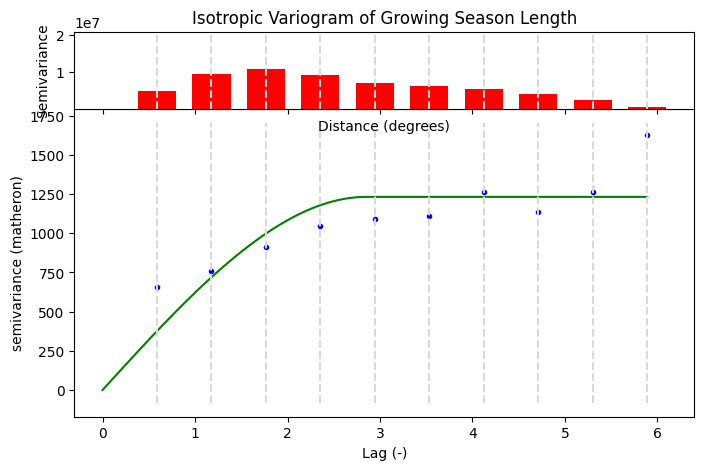

In [4]:
# ISOTROPIC VARIOGRAM ON GSL

coords = pa_gs[['latitude', 'longitude']].values
values = pa_gs['growing_season_length'].values

vario = Variogram(coords, values)

plt.figure(figsize=(10, 6))
vario.plot()
plt.xlabel('Distance (degrees)')
plt.ylabel('Semivariance')
plt.title('Isotropic Variogram of Growing Season Length')
plt.show()

['MAE = 10.25825018564257',
 'MSE = 174.2708727493307',
 'RMSE = 13.201169370526639',
 'R Squared = 0.8111050764873684',
 'Adj. R Squared = 0.8098694381568057',
 'Total Data Points = 7233',
 '(Reference) predicted variable standard deviation = 31.23174',
                       variable  var standard dev  coefficient
 0                   dtr_annual           1.42052    -13.66920
 1                   dtr_spring           1.62191      0.44842
 2                   dtr_summer           1.85314      1.49569
 3                  tmax_annual           1.73240      7.83147
 4               prcp_annual_mm         210.58578    -14.00453
 5       prcp_growing_season_mm         170.51672     19.66358
 6               prcp_spring_mm          76.52566      3.04974
 7                     latitude           0.65895     -8.61432
 8                    longitude           1.76333      8.83282
 9                  elevation_m         164.23514     -4.29876
 10               dist_coast_km          60.51768   

<Figure size 1000x600 with 0 Axes>

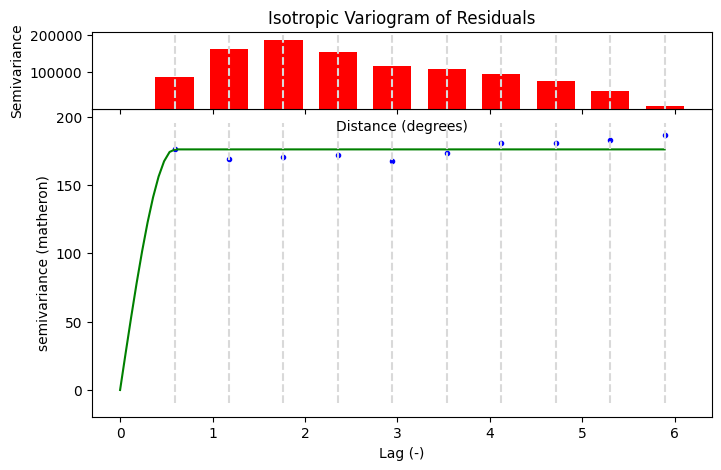

In [5]:
#AND ISOTROPIC VARIOGRAM ON RESIDUALS FROM LINEAR REGRESSION
reg_residuals, X_tests = multiple_regression(pa_gs, X, y)

cleaned_latlon = X_tests[['latitude', 'longitude']]
coords = cleaned_latlon.values
values = reg_residuals.values

vario = Variogram(coords, values)

plt.figure(figsize=(10, 6))
vario.plot()
plt.xlabel('Distance (degrees)')
plt.ylabel('Semivariance')
plt.title('Isotropic Variogram of Residuals')
plt.show()

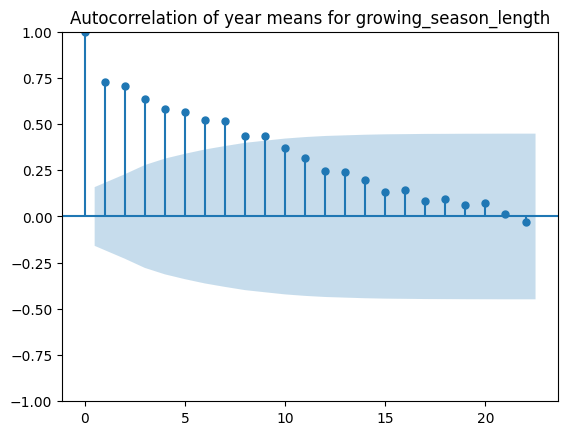

In [6]:
#TEMPORAL AUTOCORRELATION FOR GSL STATEWIDE
temp_ac_plot(pa_gs, 'year', 'growing_season_length')

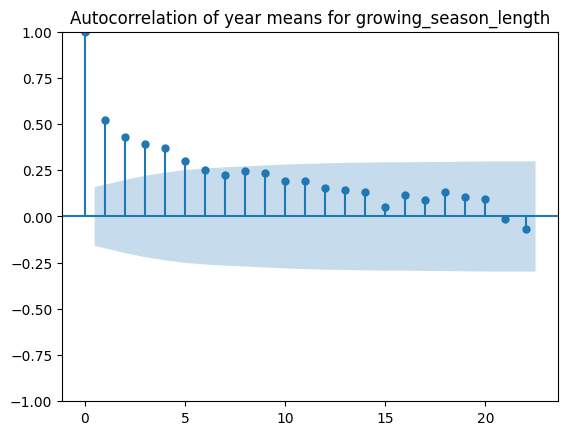

In [8]:
#TEMPORAL AUTOCORRELATION ON COASTAL STATION GSL
temp_ac_plot(coastal_pa_stations, 'year', 'growing_season_length')

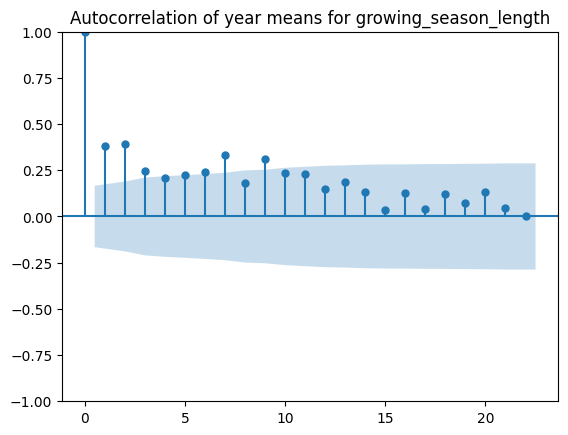

In [9]:
#TEMPORAL AUTOCORRELATION ON INLAND STATION GSL
temp_ac_plot(inland_pa_stations, 'year', 'growing_season_length')

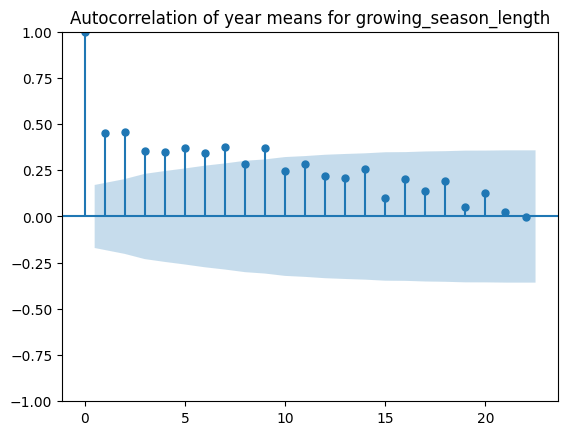

In [10]:
#TEMPORAL AUTOCORRELATION ON LAKESIDE STATION GSL
temp_ac_plot(lakeside_pa_stations, 'year', 'growing_season_length')

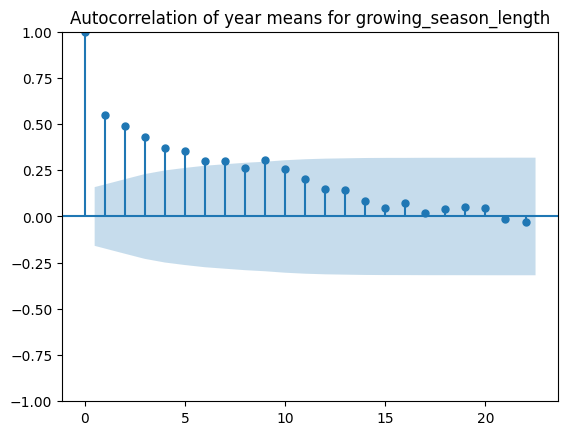

In [11]:
pa_gs_e = pa_gs[pa_gs['dist_atlantic_km'] < pa_gs['dist_greatlakes_km']]
pa_gs_w = pa_gs[pa_gs['dist_atlantic_km'] > pa_gs['dist_greatlakes_km']]

#TEMPORAL AUTOCORRELATION FOR SITES CLOSER TO ATLANTIC THAN LAKE ERIE
temp_ac_plot(pa_gs_e, 'year', 'growing_season_length')

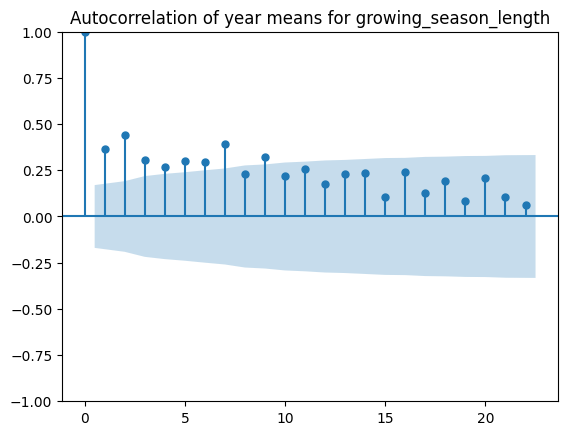

In [12]:
#TEMPORAL AUTOCORRELATION FOR SITES CLOSER TO LAKE ERIE THAN ATLANTIC
temp_ac_plot(pa_gs_w, 'year', 'growing_season_length')

In [23]:
#ROTATION OF PRINCIPAL COMPONENTS
#REFER TO Principal_Component_Analysis.ipynb FOR THIS CODE ...
# WORKS PERFECTLY IN THAT NOTEBOOK BUT WHEN COPY/PASTED INTO THIS ONE BREAKS ENTIRELY FOR NO APPARENT REASON

## Results and figures

#### Potential Guiding Questions
* How has Temporal Autocorrelation in Growing Season Length across PA changed under anthropogenic climate change, and what factors have taken the greatest role in driving any change found?
* Which geographic regions of PA observe the least/most variability in growing season length, and how do atmospheric or geographic factors influence this stability/variability locally?
* In which regions of PA is temporal autocorrelation in growing season length increasing/decreasing, and what factors are causing these changes?
* How does atmospheric moisture influence variability in growing season length across PA?
* How do Diurnal Temperature Ranges influence variability in growing season length across PA? How has this influence changed with anthropogenic warming, and what future warming thresholds globally would cause the greatest changes locally? What other mechanisms influencing growing season length do changes in Diurnal Temperature Ranges influence?
* Is there a relationship between the timing of last spring frost and first fall frost in PA, and if so, what atmospheric or geographic property connects them?
* How do broader changes to atmospheric and oceanic phenomena impact PA growing season length variability? (i.e. SST, variables not local to PA, etc)
* How accurately can certain sets of atmospheric variable observations predict growing season length the following year(s)?

## Questions and blockers

- Unsure about quality of code for Isotropic Variograms
- PC rotation seemingly ineffective --> suggestions on improvement or should we just move on?

## Plan for next week

- [ ] Complete Literature review based on chosen guiding question
- [ ] Mainly TBD, awaiting instructions from meeting